# W1D5 extra — PCA and t-SNE, side by side — Lab

**Week 1 · Day 5 · Foundations** · Extra lab · optional

Today's main lab used PCA once, at the end, to get a cluster plot onto a page. This lab is about that
step itself, because it is the step where most people quietly start believing things that are not
true.

You will take 1,797 handwritten digits, each one a point in **sixty-four dimensions**, and squeeze
them onto a flat page twice: once with PCA, which keeps as much spread as it can and gives you a
muddle, and once with t-SNE, which keeps neighbours together and gives you ten clean islands. Then you
will do the one thing nobody does with a t-SNE plot — change a setting and watch the picture change.

**Time budget:** ~55 minutes. This lab is optional extra practice for Day 5.

<div dir="rtl" align="right">

# الأسبوع ١ اليوم ٥ إضافي — تحليل المكوّنات الرئيسية وt-SNE جنبًا إلى جنب

**الأسبوع ١ · اليوم ٥ · الأساسيات** · معمل إضافي · اختياري

معمل اليوم الأساسي استخدم تحليل المكوّنات الرئيسية مرة واحدة في نهايته ليضع رسم العناقيد على صفحة.
وهذا المعمل عن تلك الخطوة نفسها، لأنها الخطوة التي يبدأ عندها أكثر الناس بالاعتقاد بأشياء غير صحيحة
دون أن ينتبهوا.

ستأخذ ١٧٩٧ رقمًا مكتوبًا بخطّ اليد، كلٌّ منها نقطة في **أربعة وستّين بُعدًا**، وتضغطها على صفحة مسطّحة
مرّتين: مرة بتحليل المكوّنات الرئيسية الذي يحفظ أكبر قدر من التشتّت فيعطيك خليطًا، ومرة بـt-SNE الذي
يُبقي الجيران معًا فيعطيك عشر جزر نظيفة. ثم تفعل الشيء الذي لا يفعله أحد مع رسم t-SNE — تغيّر إعدادًا
وتراقب الصورة وهي تتغيّر.

**الزمن المتوقّع:** نحو ٥٥ دقيقة. هذا المعمل إضافي اختياري لليوم الخامس.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Project high-dimensional data to two dimensions with PCA and read `explained_variance_ratio_`.
- Use the cumulative variance curve to answer "how many components do I actually need".
- Run t-SNE, and say in one sentence what it optimises that PCA does not.
- Name three things a t-SNE picture does not tell you, having watched one of them change.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- أن تُسقِط بيانات عالية الأبعاد إلى بُعدين بتحليل المكوّنات الرئيسية وتقرأ `explained_variance_ratio_`.
- أن تستخدم منحنى التباين التراكمي للإجابة عن سؤال «كم مكوّنًا أحتاج فعلًا».
- أن تُشغّل t-SNE وتقول في جملة واحدة ما الذي يُحسّنه ولا يُحسّنه تحليل المكوّنات الرئيسية.
- أن تذكر ثلاثة أشياء لا يخبرك بها رسم t-SNE، بعد أن رأيت أحدها يتغيّر أمامك.

</div>

## About the data

**Dataset:** `load_digits` — optical recognition of handwritten digits · CC BY 4.0 · 1,797 rows

This is the one lab in the course that does **not** call `get_dataset`. The digits ship inside
scikit-learn itself, so there is nothing to download and nothing in `shared/datasets.yaml`: a single
`load_digits()` call and you have the data, on any machine, offline.

Each row is one 8×8 greyscale image flattened into 64 numbers, each 0 to 16, plus a true label 0–9
with roughly 180 examples of each digit. The labels are used **only for colour** here — neither PCA
nor t-SNE ever sees them.

**Watch out:** these are 8×8 thumbnails from a 1990s UCI benchmark, not photographs. They separate far
more neatly than real data ever will, which is exactly why they make the contrast between the two
methods easy to see — and why the neatness is not evidence about anything else.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `load_digits` — تعرّف بصري على أرقام مكتوبة بخطّ اليد · رخصة CC BY 4.0 · ١٧٩٧ صفًّا

هذا هو المعمل الوحيد في الدورة الذي **لا** يستدعي `get_dataset`. فالأرقام تأتي داخل scikit-learn
نفسها، فلا شيء لتنزيله ولا شيء في `shared/datasets.yaml`: استدعاء واحد لـ`load_digits()` وتصير
البيانات بين يديك، على أي جهاز وبلا إنترنت.

كل صفّ صورة رمادية ٨×٨ مفرودة في ٦٤ رقمًا، كلٌّ منها بين صفر و١٦، مع تسمية حقيقية من ٠ إلى ٩ بنحو ١٨٠
مثالًا لكل رقم. والتسميات تُستخدم هنا **للتلوين فقط** — فلا تحليل المكوّنات الرئيسية ولا t-SNE يراها
إطلاقًا.

**انتبه:** هذه صور مصغّرة ٨×٨ من مرجع UCI من التسعينيات لا صور فوتوغرافية. وهي تنفصل بنظافة تفوق أي
بيانات حقيقية، وهذا بالضبط ما يجعل الفرق بين الطريقتين سهل الرؤية — وما يجعل تلك النظافة ليست دليلًا
على أي شيء آخر.

</div>

## Setup

Run the cell below first. It loads the digits, and defines `scatter_2d(ax, Z, labels, title)` — it
scatters any two-column array coloured by digit and returns the handle so you can attach a colourbar.
Both projections in this lab are drawn with it, so the two pictures are directly comparable.

<div dir="rtl" align="right">

## التهيئة

شغّل الخلية أدناه أولًا. تُحمّل الأرقام، وتُعرّف `scatter_2d(ax, Z, labels, title)` التي تنثر أي
مصفوفة من عمودين ملوّنة بحسب الرقم وتُرجع المقبض لتربط به شريط الألوان. وكلا الإسقاطين في هذا المعمل
يُرسمان بها، فتكون الصورتان قابلتين للمقارنة مباشرة.

</div>

In [1]:
# === AIEP portable setup — works locally (Miniconda + uv) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    # A clone that never ran `uv pip install -e shared/` still has the package on disk —
    # use it before reaching for the network. Colab (no clone) falls through to pip.
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, report

ensure("scikit-learn", "matplotlib")
seed_everything(42)

import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

from aiep.viz import use_course_style
use_course_style()

digits = load_digits()
X = digits.data                 # 1797 x 64 — one row per image, values 0 to 16
y = digits.target               # the true digit. Used for colour only.
IMAGES = digits.images          # the same rows, kept as 8 x 8 for the picture grid


def scatter_2d(ax, Z, labels, title):
    """Scatter a 2-D projection coloured by true digit. Written for you."""
    points = ax.scatter(Z[:, 0], Z[:, 1], c=labels, cmap="tab10", s=8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return points


print(f"{X.shape[0]:,} images x {X.shape[1]} columns | pixel range {X.min():.0f} to {X.max():.0f}")
print(f"digits present: {np.bincount(y).tolist()}")
print("\n", versions())

1,797 images x 64 columns | pixel range 0 to 16
digits present: [178, 182, 177, 183, 181, 182, 181, 179, 174, 180]

 python 3.13.15 | numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1 | torch 2.11.0+cpu | transformers 5.16.1


## Section 1 — Warm-up: look at the data, then at the problem  (≈10 min)

Before projecting anything, look at what a row actually is. It takes one cell, and it makes the rest
of the lab concrete instead of abstract.

<div dir="rtl" align="right">

## القسم الأول — الإحماء: انظر إلى البيانات ثم إلى المسألة (نحو ١٠ دقائق)

قبل إسقاط أي شيء، انظر إلى ما هو الصفّ فعلًا. يستغرق ذلك خلية واحدة، ويجعل بقية المعمل ملموسة بدل أن
تكون مجرّدة.

</div>

### Task 1.1 — draw twenty-five digits

Plot the first 25 images from `IMAGES` in a 5×5 grid, each titled with its true label. Use
`ax.imshow(image, cmap="gray_r")` and turn the ticks off — axis numbers on an 8×8 thumbnail are noise.

Then note what you are actually holding: 64 numbers per image, and no way to plot 64 axes.

<div dir="rtl" align="right">

### المهمة ١٫١ — ارسم خمسة وعشرين رقمًا

ارسم أول ٢٥ صورة من `IMAGES` في شبكة ٥×٥، مع عنونة كلٍّ منها بتسميتها الحقيقية. استخدم
`ax.imshow(image, cmap="gray_r")` وأطفئ العلامات — فأرقام المحاور على صورة ٨×٨ ضجيج.

ثم لاحظ ما تحمله فعلًا: ٦٤ رقمًا لكل صورة، ولا سبيل إلى رسم ٦٤ محورًا.

</div>

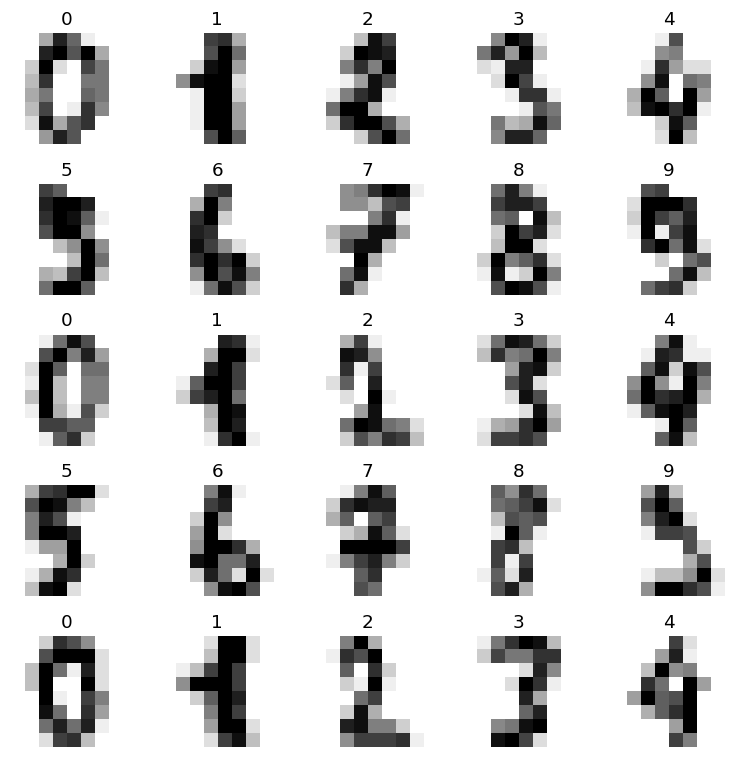

one image is 8 x 8 pixels = 64 numbers in a row
first row, first 16 numbers: [0, 0, 5, 13, 9, 1, 0, 0, 0, 0, 13, 15, 10, 15, 5, 0]


In [2]:
# ────────────────────────────────────────────────────────────────────
# 1) plt.subplots(5, 5, figsize=(7, 7)) gives you a 2-D array of axes; axes.ravel()
#    flattens it so you can zip it with the images.
# 2) zip(IMAGES[:25], y[:25], axes.ravel()) walks image, label and axes together.
# 3) ax.imshow(image, cmap="gray_r") draws it; ax.set_axis_off() removes the ticks.
# 4) plt.tight_layout() before plt.show(), or the 25 titles collide.
# Search: "matplotlib subplots grid imshow set_axis_off"
# https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html
#
# ١) السطر plt.subplots(5, 5, figsize=(7, 7)) يعطيك مصفوفة محاور ثنائية البعد، و
#    axes.ravel() تفردها لتقرنها بالصور.
# ٢) الدالة zip(IMAGES[:25], y[:25], axes.ravel()) تمشي بالصورة والتسمية والمحاور معًا.
# ٣) والسطر ax.imshow(image, cmap="gray_r") يرسمها، وax.set_axis_off() يزيل العلامات.
# ٤) استدعِ plt.tight_layout() قبل plt.show() وإلا تصادمت العناوين الخمسة والعشرون.
# ابحث عن: "matplotlib subplots grid imshow set_axis_off"
# ────────────────────────────────────────────────────────────────────

# TODO: Draw the first 25 digits in a 5x5 grid, each titled with its true label.
# مهمة: ارسم أول ٢٥ رقمًا في شبكة ٥×٥، مع عنونة كلٍّ منها بتسميتها الحقيقية.


fig, axes = plt.subplots(5, 5, figsize=(7, 7))

for image, label, ax in zip(IMAGES[:25], y[:25], axes.ravel()):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(str(label))
    ax.set_axis_off()

plt.tight_layout()
plt.show()


print(f"one image is {IMAGES[0].shape[0]} x {IMAGES[0].shape[1]} pixels "
      f"= {X.shape[1]} numbers in a row")
print(f"first row, first 16 numbers: {X[0, :16].astype(int).tolist()}")

Sixty-four numbers, and a person can read the picture instantly. That gap is the whole subject: the
information is obviously there, and it is spread across sixty-four axes in a way no eye can follow.

Dimensionality reduction is the attempt to keep what matters and throw the axes away. Every method
does it by deciding what "matters" means, and the two in this lab decide differently — which is why
they produce different pictures of identical data.

<div dir="rtl" align="right">

أربعة وستّون رقمًا، والإنسان يقرأ الصورة فورًا. وتلك الفجوة هي الموضوع كلّه: فالمعلومة موجودة بوضوح،
وهي موزّعة على أربعة وستّين محورًا بطريقة لا تستطيع العين تتبّعها.

وتقليل الأبعاد محاولة للاحتفاظ بما يهمّ والتخلّص من المحاور. وكل طريقة تفعل ذلك بأن تُقرّر ما معنى
«يهمّ»، والطريقتان في هذا المعمل تُقرّران على نحوين مختلفين — ولهذا تُنتجان صورتين مختلفتين لبيانات
متطابقة.

</div>

## Section 2 — Core: two ways onto a page  (≈35 min)

PCA asks: which two directions through this 64-dimensional cloud have the most spread along them? It
then projects everything onto those two. It is a rotation and a drop — nothing is bent.

t-SNE asks a different question, and Task 2.3 is where you meet it.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: طريقتان إلى الصفحة (نحو ٣٥ دقيقة)

يسأل تحليل المكوّنات الرئيسية: أيّ اتّجاهين عبر هذه السحابة ذات الأربعة والستّين بُعدًا فيهما أكبر
تشتّت؟ ثم يُسقط كل شيء عليهما. إنه دوران ثم إسقاط — ولا يُثنى فيه شيء.

أما t-SNE فيسأل سؤالًا مختلفًا، والمهمة ٢٫٣ هي حيث تلتقي به.

</div>

### Task 2.1 — PCA to two dimensions

Fit `PCA(n_components=2, random_state=42)` on `X`, put the result in `Z_pca`, and scatter it with
`scatter_2d` coloured by `y`. Add a colourbar so the digits can be told apart.

Then print `explained_variance_ratio_` and its sum — the share of the original spread that survived
the projection.

<div dir="rtl" align="right">

### المهمة ٢٫١ — تحليل المكوّنات الرئيسية إلى بُعدين

درّب `PCA(n_components=2, random_state=42)` على `X`، وضع النتيجة في `Z_pca`، وانثرها بـ`scatter_2d`
ملوّنة بـ`y`. وأضف شريط ألوان ليمكن تمييز الأرقام.

ثم اطبع `explained_variance_ratio_` ومجموعها — أي حصّة التشتّت الأصلي التي نجت من الإسقاط.

</div>

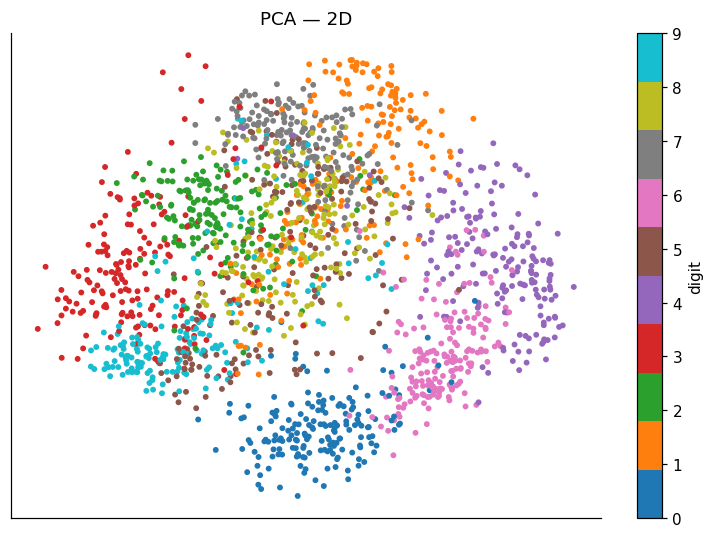

component 1 keeps 0.1489 of the variance
component 2 keeps 0.1362
two components together: 0.2851


In [3]:
# ────────────────────────────────────────────────────────────────────
# 1) PCA is imported for you. fit_transform(X) does both steps and returns the 2 columns.
# 2) Name the result `Z_pca` — every later cell and the sanity check read it.
# 3) scatter_2d returns the handle; pass it to fig.colorbar(handle, ax=ax, label="digit").
# 4) The fitted object carries explained_variance_ratio_, one number per component.
# Search: "sklearn PCA fit_transform explained_variance_ratio_"
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
#
# ١) الصنف PCA مستورد لك. والدالة fit_transform(X) تؤدّي الخطوتين وتُرجع العمودين.
# ٢) سمِّ النتيجة `Z_pca` — فكل خلية تالية والفحص يقرؤونها.
# ٣) تُرجع scatter_2d المقبض؛ مرّره إلى fig.colorbar(handle, ax=ax, label="digit").
# ٤) الكائن المُدرَّب يحمل explained_variance_ratio_، رقمًا لكل مكوّن.
# ابحث عن: "sklearn PCA fit_transform explained_variance_ratio_"
# ────────────────────────────────────────────────────────────────────

# TODO: Project X to two dimensions with PCA into `Z_pca`, plot it coloured by digit, and report how much of the variance the two components kept.
# مهمة: أسقِط X إلى بُعدين بتحليل المكوّنات الرئيسية في `Z_pca`، وارسمه ملوّنًا بالرقم، واذكر كم من التباين احتفظ به المكوّنان.


pca = PCA(n_components=2, random_state=42)

Z_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 5))

handle = scatter_2d(
    ax,
    Z_pca,
    y,
    "PCA — 2D"
)

fig.colorbar(handle, ax=ax, label="digit")

plt.tight_layout()
plt.show()

variance_kept = pca.explained_variance_ratio_.sum()


print(f"component 1 keeps {pca.explained_variance_ratio_[0]:.4f} of the variance")
print(f"component 2 keeps {pca.explained_variance_ratio_[1]:.4f}")
print(f"two components together: {variance_kept:.4f}")

In [ ]:
#Takeaway: PCA preserves variance, not class separation.

Twenty-nine percent, and a plot where 0, 6 and 4 have found their own corners while 1, 7, 8 and 9 sit
in a heap in the middle. Both facts are the same fact.

PCA was not trying to separate the digits. It was told to keep variance, and it kept as much as two
directions can hold — 29% of it. The other 71% is not on the page, and a lot of what distinguishes a 9
from a 7 lives in that 71%. The method did its job; its job was never the one you wanted.

<div dir="rtl" align="right">

تسع وعشرون بالمئة، ورسم فيه وجد الصفر والستّة والأربعة زواياها بينما يجلس الواحد والسبعة والثمانية
والتسعة في كومة في الوسط. والحقيقتان حقيقة واحدة.

فتحليل المكوّنات الرئيسية لم يكن يحاول فصل الأرقام. بل طُلب منه حفظ التباين، فحفظ أكبر قدر يسع
اتّجاهين — ٢٩٪ منه. والـ٧١٪ الباقية ليست على الصفحة، وكثير ممّا يميّز التسعة عن السبعة يعيش في تلك
الـ٧١٪. أدّى النموذج عمله؛ لكن عمله لم يكن قطّ ما أردته أنت.

</div>

### Task 2.2 — how many components would be enough

Two was a choice made so the result would fit on a page. Ask the data what it actually needs.

Fit `PCA()` with no `n_components` — it keeps all 64 — take the cumulative sum of
`explained_variance_ratio_`, and plot it against the component number. Then find the smallest number
of components reaching 90% and 95%.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — كم مكوّنًا يكفي

اختير الاثنان ليتّسع الناتج لصفحة. فاسأل البيانات عمّا تحتاجه فعلًا.

درّب `PCA()` بلا `n_components` — فيحتفظ بالأربعة والستّين كلّها — وخذ المجموع التراكمي لـ
`explained_variance_ratio_`، وارسمه مقابل رقم المكوّن. ثم جد أصغر عدد مكوّنات يبلغ ٩٠٪ و٩٥٪.

</div>

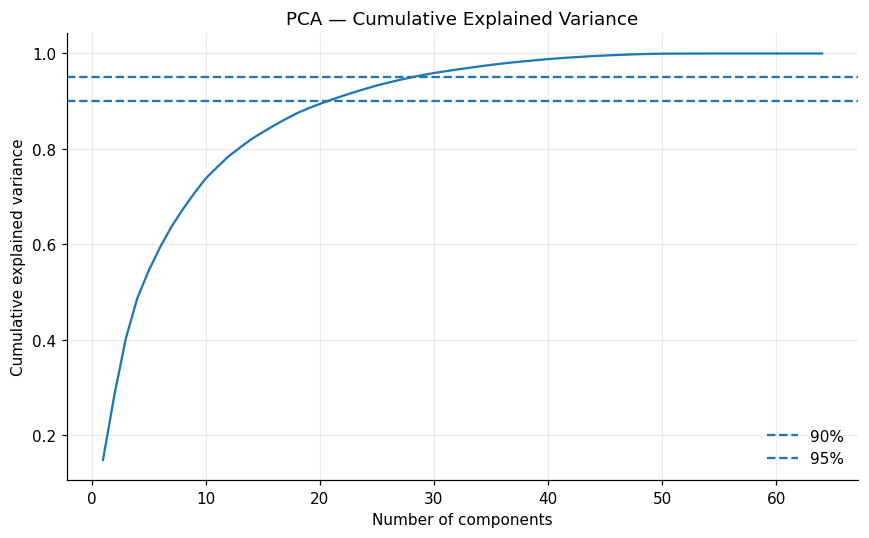

components for 90% of the variance : 21 of 64
components for 95%                 : 29 of 64
first two only                     : 0.2851


In [4]:
# ────────────────────────────────────────────────────────────────────
# 1) np.cumsum(ratios) turns "how much each component keeps" into "how much the first n keep".
# 2) np.argmax(cumulative >= 0.90) gives the first position where the curve crosses 0.90.
#    Positions count from 0, so add 1 to get a count of components.
# 3) Store the two counts as `n_for_90` and `n_for_95`; the artefact cell reads them.
# 4) Draw the curve with horizontal lines at 0.90 and 0.95 so the crossings are visible.
# Search: "numpy cumsum argmax threshold crossing"
#
# ١) الدالة np.cumsum(ratios) تحوّل «كم يحفظ كل مكوّن» إلى «كم تحفظ أول n مكوّنًا».
# ٢) والدالة np.argmax(cumulative >= 0.90) تعطي أول موضع يعبر فيه المنحنى ٠٫٩٠.
#    والمواضع تُعدّ من الصفر، فأضف واحدًا لتحصل على عدد المكوّنات.
# ٣) خزّن العددين باسمي `n_for_90` و`n_for_95`؛ فخلية الحفظ تقرؤهما.
# ٤) ارسم المنحنى مع خطّين أفقيّين عند ٠٫٩٠ و٠٫٩٥ لتظهر نقطتا العبور.
# ابحث عن: "numpy cumsum argmax threshold crossing"
# ────────────────────────────────────────────────────────────────────

# TODO: Fit PCA with all components, plot the cumulative variance curve, and find how many components reach 90% and 95%.
# مهمة: درّب PCA بكل المكوّنات، وارسم منحنى التباين التراكمي، وجد كم مكوّنًا يبلغ ٩٠٪ و٩٥٪.


pca_full = PCA()

pca_full.fit(X)

ratios = pca_full.explained_variance_ratio_
cumulative = np.cumsum(ratios)

n_for_90 = np.argmax(cumulative >= 0.90) + 1
n_for_95 = np.argmax(cumulative >= 0.95) + 1

components = np.arange(1, len(cumulative) + 1)

plt.figure(figsize=(8, 5))

plt.plot(components, cumulative)

plt.axhline(0.90, linestyle="--", label="90%")
plt.axhline(0.95, linestyle="--", label="95%")

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()

plt.tight_layout()
plt.show()


print(f"components for 90% of the variance : {n_for_90} of {X.shape[1]}")
print(f"components for 95%                 : {n_for_95} of {X.shape[1]}")
print(f"first two only                     : {cumulative[1]:.4f}")

In [ ]:
#Takeaway: PCA reduces dimensions by preserving variance. In this lab, 2 components kept only 28.51% of the variance,
# while 21 components kept 90% and 29 kept 95%. Therefore, PCA is more useful for dimensionality reduction/compression than for 2D visualization.

Twenty-one columns instead of sixty-four, and 90% of the information is still there. That is a real
result and the honest use of PCA: **compression**, not pictures. A model trained on those 21 columns
runs faster and will usually score about the same.

The two-dimensional plot from Task 2.1 was never PCA at its best. It was PCA pushed three times past
where it stops being useful, because a page has only two axes.

<div dir="rtl" align="right">

واحد وعشرون عمودًا بدل أربعة وستّين، و٩٠٪ من المعلومة ما زالت موجودة. وهذه نتيجة حقيقية والاستعمال
الصادق لتحليل المكوّنات الرئيسية: **الضغط** لا الصور. فالنموذج المُدرَّب على تلك الأعمدة الواحد
والعشرين أسرع، ونتيجته في العادة قريبة من الأصل.

أما الرسم ثنائي البعد في المهمة ٢٫١ فلم يكن قطّ أفضل ما يقدّمه التحليل. بل كان التحليل مدفوعًا إلى ثلاثة
أضعاف ما بعد الحدّ الذي يتوقّف عنده عن النفع، لأن الصفحة ليس فيها إلا محوران.

</div>

### Task 2.3 — t-SNE, and what it optimises instead

t-SNE does not look for directions. It looks at which points are close to which in the original 64
dimensions, and then arranges points on the page so that those neighbourhoods survive. Global
distances are not in the objective at all.

Fit `TSNE(n_components=2, init="pca", perplexity=30, random_state=42)` into `Z_tsne`, and plot it
beside the PCA panel. It takes a couple of seconds — t-SNE looks at pairs of points, not columns.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — t-SNE وما الذي يُحسّنه بدلًا من ذلك

لا يبحث t-SNE عن اتّجاهات. بل ينظر في أي النقاط قريبة من أيّها في الأبعاد الأربعة والستّين الأصلية، ثم
يرتّب النقاط على الصفحة بحيث تبقى تلك الجيرة. أما المسافات الكلّية فليست في دالة الهدف إطلاقًا.

درّب `TSNE(n_components=2, init="pca", perplexity=30, random_state=42)` في `Z_tsne`، وارسمه بجوار
لوحة تحليل المكوّنات الرئيسية. ويستغرق ذلك ثانيتين — فـt-SNE ينظر في أزواج النقاط لا في الأعمدة.

</div>

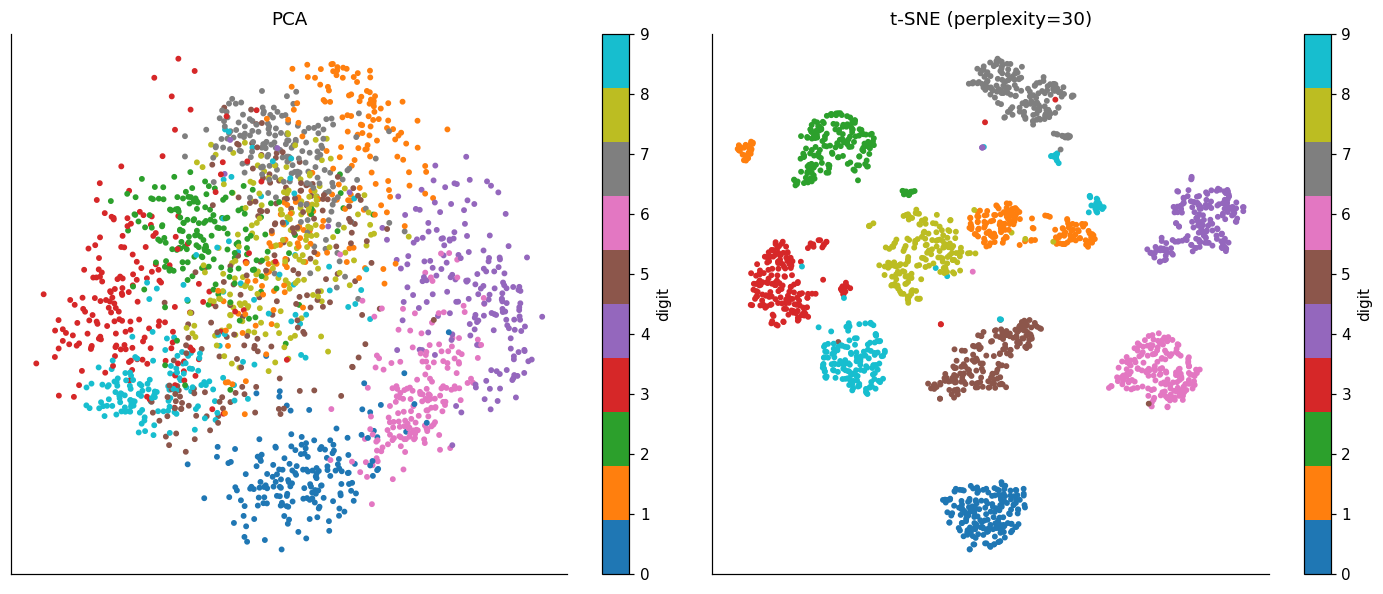

silhouette on the PCA picture   : 0.1051
silhouette on the t-SNE picture : 0.5549


In [5]:
# ────────────────────────────────────────────────────────────────────
# 1) TSNE has fit_transform like PCA, but no transform — it cannot embed new points later.
#    That is a real limitation, not an oversight.
# 2) init="pca" makes the run reproducible and faster; random_state=42 pins the rest.
# 3) Name it `Z_tsne`, then draw both panels with plt.subplots(1, 2, figsize=(13, 5.5)).
# 4) Then measure both: silhouette_score(Z, y) says how well separated the true digits are
#    in each picture. Store them as `sil_pca` and `sil_tsne`.
# Search: "sklearn TSNE perplexity init pca fit_transform"
# https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
#
# ١) في TSNE دالة fit_transform كما في PCA، لكن لا transform — فلا يستطيع تضمين نقاط جديدة
#    لاحقًا. وهذا قيد حقيقي لا سهو.
# ٢) والوسيط init="pca" يجعل التشغيل قابلًا لإعادة الإنتاج وأسرع، وrandom_state=42 يثبّت الباقي.
# ٣) سمِّه `Z_tsne`، ثم ارسم اللوحتين بـplt.subplots(1, 2, figsize=(13, 5.5)).
# ٤) ثم قِس الاثنتين: silhouette_score(Z, y) يقول كم انفصلت الأرقام الحقيقية في كل صورة.
#    خزّنهما باسمي `sil_pca` و`sil_tsne`.
# ابحث عن: "sklearn TSNE perplexity init pca fit_transform"
# ────────────────────────────────────────────────────────────────────

# TODO: Project X to two dimensions with t-SNE into `Z_tsne`, plot it beside the PCA panel, and measure both with silhouette_score into `sil_pca` and `sil_tsne`.
# مهمة: أسقِط X إلى بُعدين بـt-SNE في `Z_tsne`، وارسمه بجوار لوحة PCA، وقِس الاثنتين بـ silhouette_score في `sil_pca` و`sil_tsne`.


tsne = TSNE(
    n_components=2,
    init="pca",
    perplexity=30,
    random_state=42
)

Z_tsne = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

p1 = scatter_2d(axes[0], Z_pca, y, "PCA")
p2 = scatter_2d(axes[1], Z_tsne, y, "t-SNE (perplexity=30)")

fig.colorbar(p1, ax=axes[0], label="digit")
fig.colorbar(p2, ax=axes[1], label="digit")

plt.tight_layout()
plt.show()

sil_pca = silhouette_score(Z_pca, y)
sil_tsne = silhouette_score(Z_tsne, y)


print(f"silhouette on the PCA picture   : {sil_pca:.4f}")
print(f"silhouette on the t-SNE picture : {sil_tsne:.4f}")

In [ ]:
# Takeaway: t-SNE is mainly a visualization tool. It preserves local neighborhoods,
# but global distances and island sizes should not be interpreted. It also cannot directly transform new points in scikit-learn.

Ten islands, one per digit, and a silhouette five times the PCA one — on identical data, with neither
method ever shown a label.

Now the part that matters more than the picture. Three things this plot does **not** tell you:

- **Distances between islands mean nothing.** t-SNE only tried to keep neighbours together. The gap
  between the 3-island and the 8-island is not evidence that 3s and 8s are far apart.
- **Island sizes mean nothing.** They come from how the algorithm spread points out locally, not from
  how many points there are or how varied they are.
- **It cannot place a new point.** There is no `transform`. A digit that arrives tomorrow requires
  re-running the whole thing, and the picture will come out different.

So t-SNE is a tool for looking, and PCA is a tool for keeping. Using a t-SNE plot as an argument is
where people go wrong.

<div dir="rtl" align="right">

عشر جزر، واحدة لكل رقم، ومعامل ظلّ يبلغ خمسة أضعاف معامل PCA — على بيانات متطابقة، ودون أن ترى أيٌّ من
الطريقتين تسمية واحدة.

وأمّا الجزء الأهمّ من الصورة. ثلاثة أشياء **لا** يخبرك بها هذا الرسم:

- **المسافات بين الجزر لا تعني شيئًا.** فـt-SNE لم يحاول إلا إبقاء الجيران معًا. والفجوة بين جزيرة
  الثلاثة وجزيرة الثمانية ليست دليلًا على تباعد الثلاثات عن الثمانيات.
- **أحجام الجزر لا تعني شيئًا.** فهي ناتجة عن كيفية نشر الخوارزمية للنقاط محلّيًا، لا عن عددها ولا عن
  مدى تنوّعها.
- **لا يستطيع وضع نقطة جديدة.** فلا توجد دالة `transform`. والرقم الذي يصل غدًا يستلزم إعادة تشغيل
  كل شيء، وستخرج الصورة مختلفة.

فـt-SNE أداة للنظر، وتحليل المكوّنات الرئيسية أداة للحفظ. واستعمال رسم t-SNE حجّةً هو موضع خطأ الناس.

</div>

## Section 3 — Stretch: turn the knob  (≈10 min)

Open-ended, and lower expectation of completeness. Finish it at home if the room moves on.

`perplexity` is roughly "how many neighbours each point should try to stay near". It is the one
setting that changes a t-SNE picture the most, and almost nobody reports which value they used.

Run t-SNE at each value in `PERPLEXITIES` and draw the three results in a row, each titled with its
perplexity and silhouette. Identical data every time.

<div dir="rtl" align="right">

## القسم الثالث — إضافي: أدِر المفتاح (نحو ١٠ دقائق)

مفتوح، والتوقّع فيه أقلّ من حيث الاكتمال. أكمله في المنزل إن مضت القاعة.

الوسيط `perplexity` يعني تقريبًا «كم جارًا ينبغي لكل نقطة أن تحاول البقاء قربهم». وهو الإعداد الأكثر
تغييرًا لصورة t-SNE، ولا يكاد أحد يذكر القيمة التي استعملها.

شغّل t-SNE عند كل قيمة في `PERPLEXITIES` وارسم النتائج الثلاث في صفّ، مع عنونة كلٍّ منها بقيمتها
ومعامل ظلّها. والبيانات متطابقة في كل مرة.

</div>

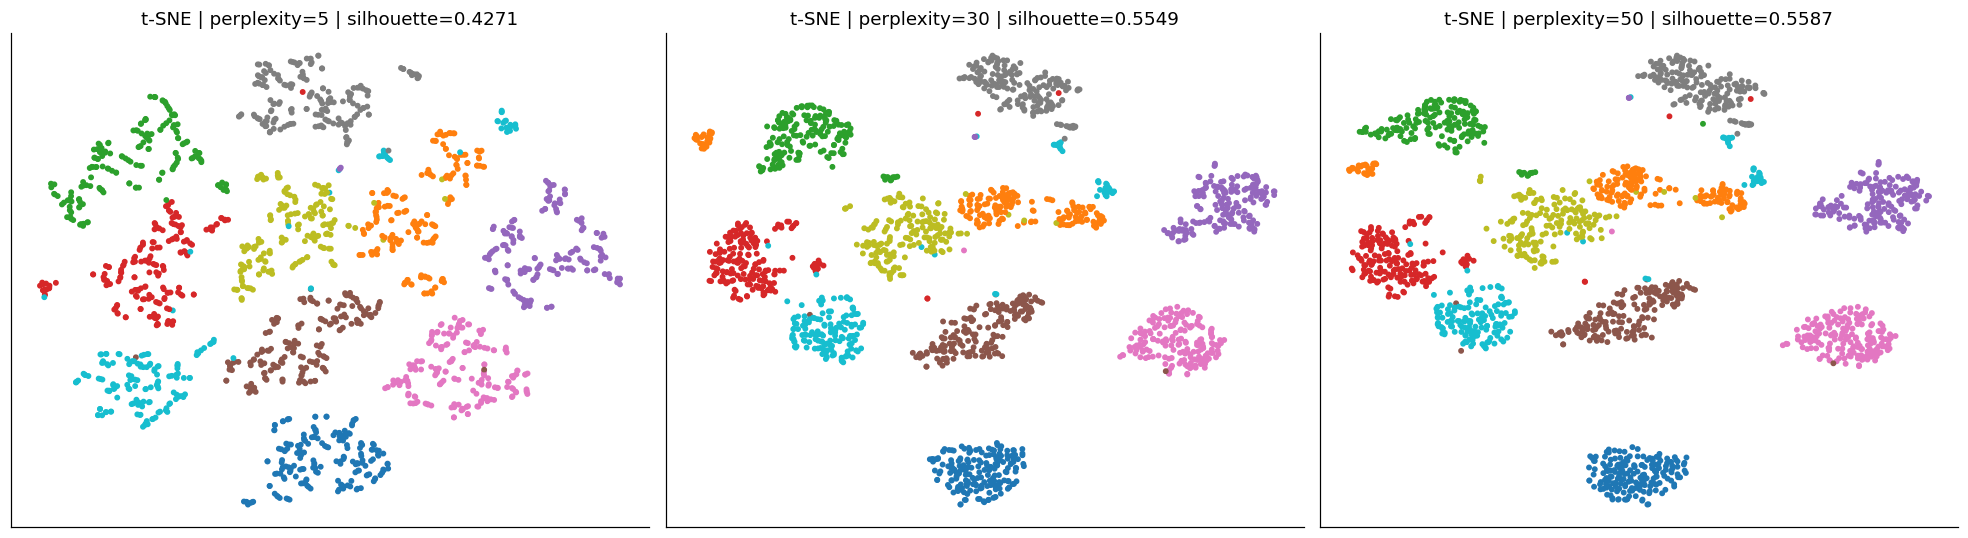

perplexity   5 -> silhouette 0.4271
perplexity  30 -> silhouette 0.5549
perplexity  50 -> silhouette 0.5587


In [7]:
# ────────────────────────────────────────────────────────────────────
# 1) Same loop shape as the C sweep on Thursday: zip PERPLEXITIES with three axes.
# 2) Inside: TSNE(n_components=2, init="pca", perplexity=value, random_state=42).
# 3) Score each with silhouette_score against y and put it in the panel title.
# 4) Three t-SNE runs take a few seconds. Do not reduce the data to speed it up — the
#    picture changes when the number of points changes, which would confuse the comparison.
# Search: "sklearn TSNE perplexity effect interpretation"
#
# ١) الحلقة نفسها في مسح C يوم الخميس: اقرن PERPLEXITIES بثلاثة محاور بـzip.
# ٢) وداخلها: TSNE(n_components=2, init="pca", perplexity=value, random_state=42).
# ٣) قيّم كلًّا منها بـsilhouette_score مقابل y وضع النتيجة في عنوان اللوحة.
# ٤) ثلاث تشغيلات لـt-SNE تستغرق ثوانٍ قليلة. ولا تُصغّر البيانات لتسريعها — فالصورة تتغيّر
#    بتغيّر عدد النقاط، وذلك يُربك المقارنة.
# ابحث عن: "sklearn TSNE perplexity effect interpretation"
# ────────────────────────────────────────────────────────────────────

PERPLEXITIES = [5, 30, 50]
# TODO: Run t-SNE at each perplexity, draw the three pictures in a row, and collect their silhouette scores into `perplexity_scores`.
# مهمة: شغّل t-SNE عند كل قيمة perplexity، وارسم الصور الثلاث في صفّ، واجمع معاملات الظلّ في `perplexity_scores`.


perplexity_scores = {}

fig, axes = plt.subplots(1, len(PERPLEXITIES), figsize=(18, 5))

for value, ax in zip(PERPLEXITIES, axes):
    tsne_p = TSNE(
        n_components=2,
        init="pca",
        perplexity=value,
        random_state=42
    )

    Z = tsne_p.fit_transform(X)

    score = silhouette_score(Z, y)
    perplexity_scores[value] = float(score)

    scatter_2d(
        ax,
        Z,
        y,
        f"t-SNE | perplexity={value} | silhouette={score:.4f}"
    )

plt.tight_layout()
plt.show()



for value, score in perplexity_scores.items():
    print(f"perplexity {value:>3} -> silhouette {score:.4f}")

In [ ]:
#Takeaway: A t-SNE plot can change substantially with perplexity,
# so one visualization should not be treated as the complete or definitive structure of the data.

**Your answer:** I might wrongly conclude that the digits are naturally less separated, when the appearance is partly influenced by the chosen perplexity.

<div dir="rtl" align="right">

**إجابتك:** قد أستنتج بالخطأ أن الأرقام أقل تباعداً بطبيعتها، في حين أن هذا المظهر يتأثر جزئياً بقيمة التعقيد (perplexity) المختارة.

</div>

## Save your artefact

`pca_tsne_intro.json` records how much variance two components kept, how many components you would
actually need, and the two silhouette scores. Keep it: in Week 6 you will produce embeddings of your
own and want to look at them, and the three cautions above apply there unchanged.

<div dir="rtl" align="right">

## احفظ ناتجك

يسجّل الملف `pca_tsne_intro.json` كم من التباين حفظه مكوّنان، وكم مكوّنًا تحتاج فعلًا، ومعاملَي الظلّ.
احتفظ به: ففي الأسبوع السادس ستُنتج تمثيلات خاصة بك وستريد النظر إليها، والتحذيرات الثلاثة أعلاه
تنطبق هناك دون تغيير.

</div>

In [12]:
metrics = {
    "dataset": "sklearn load_digits",

    "n_rows": int(X.shape[0]),
    "n_columns": int(X.shape[1]),

    "variance_kept_2_components": float(round(variance_kept, 4)),

    "components_for_90_percent": int(n_for_90),
    "components_for_95_percent": int(n_for_95),

    "silhouette_pca": float(round(sil_pca, 4)),
    "silhouette_tsne": float(round(sil_tsne, 4)),

    "silhouette_by_perplexity": {
        str(k): float(v)
        for k, v in perplexity_scores.items()
    },
}

out = ARTEFACT_DIR / "pca_tsne_intro.json"

out.write_text(
    json.dumps(metrics, indent=2),
    encoding="utf-8"
)

print(f"Saved {out}")
print(json.dumps(metrics, indent=2))

Saved /content/artefacts/pca_tsne_intro.json
{
  "dataset": "sklearn load_digits",
  "n_rows": 1797,
  "n_columns": 64,
  "variance_kept_2_components": 0.2851,
  "components_for_90_percent": 21,
  "components_for_95_percent": 29,
  "silhouette_pca": 0.1051,
  "silhouette_tsne": 0.5548999905586243,
  "silhouette_by_perplexity": {
    "5": 0.4270596206188202,
    "30": 0.5548605918884277,
    "50": 0.5586918592453003
  }
}


In [13]:
from google.colab import files

files.download(str(out))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Sanity check

Run this last. Every check that fails tells you what to fix and why.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخلية أخيرًا. كل فحص يفشل يخبرك بما يجب إصلاحه ولماذا.

</div>

In [14]:
# --- Sanity checks ----------------------------------------------------------------
check(Z_pca.shape == (X.shape[0], 2),
      f"the PCA projection must be one 2-D point per image, expected {(X.shape[0], 2)}, "
      f"got {Z_pca.shape}",
      f"يجب أن يكون إسقاط PCA نقطة ثنائية البعد لكل صورة، والمتوقّع {(X.shape[0], 2)} "
      f"والموجود {Z_pca.shape}")

check(Z_tsne.shape == (X.shape[0], 2),
      f"the t-SNE projection must have the same shape, got {Z_tsne.shape}",
      f"يجب أن يكون لإسقاط t-SNE الشكل نفسه، والموجود {Z_tsne.shape}")

check(0.20 < variance_kept < 0.45,
      f"two components on these digits keep roughly 0.29 of the variance; yours keep "
      f"{variance_kept:.4f} — if it is near 1.0 you fitted PCA on two columns, not on X",
      f"يحفظ مكوّنان على هذه الأرقام نحو ٠٫٢٩ من التباين، ونسبتك {variance_kept:.4f} — "
      f"فإن قاربت ١٫٠ فقد درّبت PCA على عمودين لا على X")

check(2 < n_for_90 < n_for_95 < X.shape[1],
      f"reaching 95% must need more components than 90%, and both fewer than all "
      f"{X.shape[1]}: got {n_for_90} and {n_for_95}",
      f"بلوغ ٩٥٪ يجب أن يحتاج مكوّنات أكثر من ٩٠٪، وكلاهما أقلّ من {X.shape[1]}: "
      f"والموجود {n_for_90} و{n_for_95}")

check(sil_tsne > sil_pca + 0.20,
      f"t-SNE should separate these digits far better than PCA: {sil_tsne:.4f} vs "
      f"{sil_pca:.4f} — if they are close, check you scored each embedding against y",
      f"يجب أن يفصل t-SNE هذه الأرقام أفضل بكثير من PCA: {sil_tsne:.4f} مقابل "
      f"{sil_pca:.4f} — فإن تقاربا فتحقّق أنك قيّمت كل إسقاط مقابل y")

check(len(perplexity_scores) == len(PERPLEXITIES),
      f"the stretch needs one score per perplexity ({len(PERPLEXITIES)}), got "
      f"{len(perplexity_scores)}",
      f"يحتاج القسم الإضافي نتيجة لكل perplexity ({len(PERPLEXITIES)})، والموجود "
      f"{len(perplexity_scores)}")

check((ARTEFACT_DIR / "pca_tsne_intro.json").exists(),
      "pca_tsne_intro.json should exist — run the save cell above",
      "يجب أن يوجد الملف pca_tsne_intro.json — شغّل خلية الحفظ أعلاه")

report()

──────────────────────────────────────────────────────────────────
  ✓  the PCA projection must be one 2-D point per image, expected (1797, 2), got (1797, 2)
  ✓  the t-SNE projection must have the same shape, got (1797, 2)
  ✓  two components on these digits keep roughly 0.29 of the variance; yours keep 0.2851 — if it is near 1.0 you fitted PCA on two columns, not on X
  ✓  reaching 95% must need more components than 90%, and both fewer than all 64: got 21 and 29
  ✓  t-SNE should separate these digits far better than PCA: 0.5549 vs 0.1051 — if they are close, check you scored each embedding against y
  ✓  the stretch needs one score per perplexity (3), got 3
  ✓  pca_tsne_intro.json should exist — run the save cell above
──────────────────────────────────────────────────────────────────
  ✅ All 7 checks passed. / اجتزت جميع الفحوصات (7).
──────────────────────────────────────────────────────────────────


## What's next

Week 1 is over. You have fitted a line, a curve, a staircase and a cluster, and every one of them came
with the same warning attached: the model will answer whatever you ask, and only you can check whether
the question made sense. Week 2 is about the data those questions are asked of.

<div dir="rtl" align="right">

## ماذا بعد

انتهى الأسبوع الأول. لقد درّبت خطًّا ومنحنى وسُلّمًا وعناقيد، وكلٌّ منها جاء ومعه التحذير نفسه: النموذج
سيُجيب عن أي سؤال تسأله، وأنت وحدك من يتحقّق هل كان السؤال ذا معنى. والأسبوع الثاني عن البيانات التي
تُسأل عنها تلك الأسئلة.

</div>